In [1]:
from modules.Reinforcementlearning import SemiGradSarsa, Tile, torch, nn, random, plt, clear_output
from time import sleep
import ipywidgets

In [2]:
class Enviroment:
    def __init__(self, left_bound, right_bound):
        self.left_bound = left_bound
        self.right_bound = right_bound
        self.x_grid = torch.linspace(left_bound, right_bound, 100)

    def hill(self, x):
        xp = torch.pi * ((x - self.left_bound) / (self.right_bound - self.left_bound))
        return torch.cos(xp) ** 2

    def gravity(self, x):
        xp = torch.pi * ((x - self.left_bound) / (self.right_bound - self.left_bound))
        scale = torch.pi / (self.right_bound - self.left_bound)
        return scale * torch.cos(xp) * torch.sin(xp)

    def print(self):
        fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6))

        ax1.plot(self.x_grid, self.hill(self.x_grid))
        ax1.set_ylabel("Hill")
        ax1.grid()

        ax2.plot(self.x_grid, self.gravity(self.x_grid), color="r")
        ax2.set_ylabel("Gravity")
        ax2.set_xlabel("x")
        ax2.grid()

        plt.tight_layout()
        plt.show()

    def setup(self):
        eps = (self.right_bound - self.left_bound) * 0.25
        x0 = random.uniform(self.left_bound + eps, self.right_bound - eps)
        return torch.tensor([x0, 0])
            
    def terminal_check(self, state):
        if state[0] > right_bound:
            return True
        return False
    
    def step(self, state, action):
        x = state[0]
        v = state[1]
        r = 0
        if v<0:
            r = 0.1
        if v>0:
            r = -0.1
        a = 0.4 * (action - 1) + self.gravity(x) + r
        xout = 0.5 * a * 0.01 + v * 0.1 + x
        vout = a * 0.1 + v
        new_state = torch.tensor([xout, vout])
        
        if xout < self.left_bound:
            return torch.tensor([self.left_bound, 0.0]), -1, False
            
        return new_state, -1, self.terminal_check(new_state)


    def test_net(self, qnet):
        try:
            while True:
                i = 0
                S = env.setup()
                goal_reached = False
                while not goal_reached:
                    i += 1
                    q_values = qnet(S)
                    A = torch.argmax(q_values)
                    S, R, goal_reached = self.step(S, A)
                    clear_output(wait=True)
                    plt.plot(self.x_grid, self.hill(self.x_grid))
                    plt.plot(S[0], self.hill(S[0]), linestyle=" ", marker="o", color="r")
                    a = A - 1
                    if a == 1:
                        plt.plot(S[0] + 0.02*a, self.hill(S[0]), linestyle=" ", marker=">", color="b")
                    if a == -1:
                        plt.plot(S[0] + 0.02*a, self.hill(S[0]), linestyle=" ", marker="<", color="b")
                    plt.title(f"Step {i}")
                    plt.show()
                    sleep(0.05)
        except KeyboardInterrupt:
            pass
    

In [3]:
class Driver(nn.Module):
    def __init__(self, tile_grid_size, tile_N_grids, left_bound=-1, right_bound=1):
        super(Driver, self).__init__()
        self.tile = Tile(tile_grid_size, tile_N_grids, left_bound, right_bound)
        self.N_actions = 3
        self.weights = nn.Parameter(torch.zeros(tile_N_grids, tile_grid_size**2, 3, requires_grad=True))

    def forward(self, S):
        tile_rep = self.tile(S)
        out = torch.zeros(self.N_actions)
        for i, index in enumerate(tile_rep):
            out += self.weights[i, index]
        return out
        

In [4]:
class NewDriver(nn.Module):
    def __init__(self, N_actions, N_inputs, width, depth):
        super(NewDriver, self).__init__()
        self.linears = [nn.Linear(N_inputs, width), nn.Softmax(0)]
        for _ in range(depth-1):
            self.linears.append(nn.Linear(width, width))
        self.softmax = nn.Softmax(0)
        self.out = nn.Linear(width, N_actions)
        
    def forward(self, S):
        out = S.detach().clone()
        for linear in self.linears:
            out = self.softmax(linear(out))
        return self.out(out)
        

In [5]:
left_bound = -1
right_bound = 1
driver = Driver(10,8, left_bound, right_bound)
# driver = NewDriver(3, 2, 10, 5)
env = Enviroment(left_bound, right_bound)
sarsa = SemiGradSarsa(env, driver)

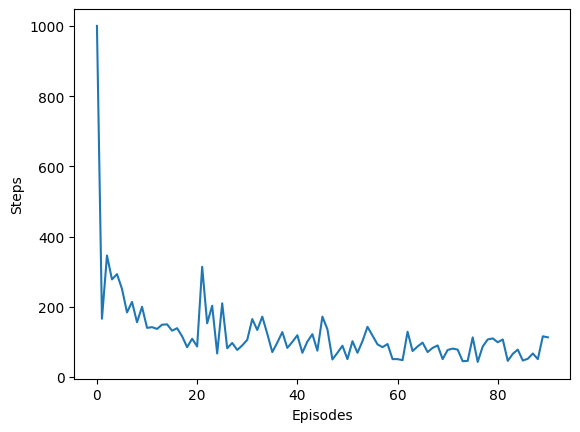

In [7]:
sarsa.run(max_episode=100)

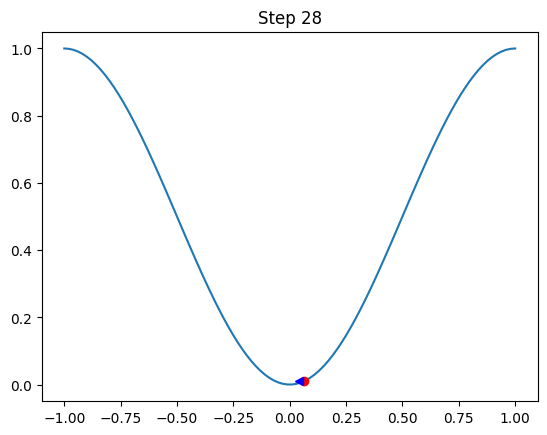

In [8]:
env.test_net(driver)